#Section 1: Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import json, os

os.makedirs('/root/.kaggle', exist_ok=True)
api_token = {"username":"YOUR_USERNAME","key":"YOUR_KEY"}
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(api_token, f)

os.chmod('/root/.kaggle/kaggle.json', 600)

In [3]:
!pip install -q kaggle

In [4]:
import os
os.makedirs('/content/drive/MyDrive/AgriSmart/model_weights', exist_ok=True)

In [5]:
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
100% 2.70G/2.70G [00:24<00:00, 119MB/s]



In [6]:
!unzip -q new-plant-diseases-dataset.zip -d /content/plant_disease_data

#Section 2: Data Exploration

In [7]:
#IMPORTING LIBRARIES
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

In [ ]:
path = '/content/plant_disease_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train'
plt.figure(figsize=(70,70))
count=0
plant_names=[]
total_images=0
for i in os.listdir(path):
  count+=1
  plant_names.append(i)
  plt.subplot(7,7,count)

  images_path=os.listdir(path+"/"+i)
  print("Number of images of "+i+":",len(images_path),"||",end=" ")
  total_images+=len(images_path)

  image_show=plt.imread(path+"/"+i+"/"+images_path[0])

  plt.imshow(image_show)
  plt.xlabel(i)

  plt.xticks([])
  plt.yticks([])


print("Total number of images we have",total_images)

In [9]:
print(plant_names)
print(len(plant_names))

['Tomato___Septoria_leaf_spot', 'Tomato___Target_Spot', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Northern_Leaf_Blight', 'Soybean___healthy', 'Tomato___Tomato_mosaic_virus', 'Grape___Esca_(Black_Measles)', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Blueberry___healthy', 'Potato___Late_blight', 'Peach___Bacterial_spot', 'Grape___Black_rot', 'Cherry_(including_sour)___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Raspberry___healthy', 'Grape___healthy', 'Pepper,_bell___healthy', 'Tomato___Leaf_Mold', 'Pepper,_bell___Bacterial_spot', 'Corn_(maize)___healthy', 'Peach___healthy', 'Potato___Early_blight', 'Strawberry___Leaf_scorch', 'Apple___Cedar_apple_rust', 'Tomato___healthy', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Apple___healthy', 'Apple___Black_rot', 'Tomato___Early_blight', 'Potato___healthy', 'Tomato___Bacterial_spot', 'Squash___Powdery_mildew', 'Corn_(maize)___Common_rust_', 'Cherry_(including_sour)___Powdery_mildew', 'Apple___Appl

#Section 3: Model Architecture


In [10]:
import tensorflow
from tensorflow import keras
from keras.models import Sequential,load_model,Model
from keras.layers import Conv2D,MaxPool2D,AveragePooling2D,Dense,Flatten,ZeroPadding2D,BatchNormalization,Activation,Add,Input,Dropout,GlobalAveragePooling2D
from keras.optimizers import SGD
from keras.initializers import glorot_uniform
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import ModelCheckpoint,EarlyStopping,ReduceLROnPlateau

In [11]:

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

In [12]:
base_model_tf=ResNet50(include_top=False,weights='imagenet',input_shape=(224,224,3),classes=38)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [13]:
#Model building
base_model_tf.trainable=False

pt=Input(shape=(224,224,3))
func=keras.layers.Lambda(lambda x: tensorflow.cast(x, tensorflow.float32))(pt)
x=preprocess_input(func) #This function used to zero-center each color channel wrt Imagenet dataset
model_resnet=base_model_tf(x,training=False)
model_resnet=GlobalAveragePooling2D()(model_resnet)
model_resnet=Dense(128,activation='relu')(model_resnet)
model_resnet=Dense(64,activation='relu')(model_resnet)
model_resnet=Dense(38,activation='softmax')(model_resnet)


model_main=Model(inputs=pt,outputs=model_resnet)
model_main.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ lambda[0][0]      │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ lambda[0][0]      │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    262,272 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 38)        │      2,470 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,860,710 (91.02 MB)

 Trainable params: 272,998 (1.04 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

#Section 4: Data generators and Augmentation

In [14]:
#Image augmentation
train_datagen = ImageDataGenerator(
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest',
    width_shift_range=0.2,
    height_shift_range=0.2,
    brightness_range=[0.7, 1.3],
    rotation_range=20
)

val_datagen = ImageDataGenerator()

path_train = '/content/plant_disease_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train'
path_valid = '/content/plant_disease_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid'

train = train_datagen.flow_from_directory(directory=path_train, batch_size=32, target_size=(224,224),
                                           color_mode='rgb', class_mode='categorical', seed=42)

valid = val_datagen.flow_from_directory(directory=path_valid, batch_size=32, target_size=(224,224),
                                         color_mode='rgb', class_mode='categorical')

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.


#Section 5: Initial Training

In [ ]:
#CallBacks
es = EarlyStopping(monitor='val_accuracy', verbose=1, patience=7, mode='auto')
mc = ModelCheckpoint(filepath='/content/drive/MyDrive/AgriSmart/model_weights/best_model.h5',
                      monitor='val_accuracy', verbose=1, save_best_only=True)
lr = ReduceLROnPlateau(monitor='val_accuracy', verbose=1, patience=5, min_lr=0.001)

In [ ]:
model_main.compile(optimizer='Adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
#Training
model_main.fit(train, validation_data=valid, epochs=30, steps_per_epoch=200, verbose=1, callbacks=[mc, es, lr])
model_main.save("/content/drive/MyDrive/AgriSmart/model_weights/RESNET50_PLANT_DISEASE.h5")

Epoch 1/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 513ms/step - accuracy: 0.3843 - loss: 2.3720
Epoch 1: val_accuracy improved from None to 0.82159, saving model to /content/drive/MyDrive/AgriSmart/model_weights/best_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/AgriSmart/model_weights/best_model.h5
200/200 ━━━━━━━━━━━━━━━━━━━━ 171s 785ms/step - accuracy: 0.5973 - loss: 1.5042 - val_accuracy: 0.8216 - val_loss: 0.6105 - learning_rate: 0.0010
Epoch 2/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 511ms/step - accuracy: 0.8145 - loss: 0.6140
Epoch 2: val_accuracy improved from 0.82159 to 0.87093, saving model to /content/drive/MyDrive/AgriSmart/model_weights/best_model.h5



Epoch 2: finished saving model to /content/drive/MyDrive/AgriSmart/model_weights/best_model.h5
200/200 ━━━━━━━━━━━━━━━━━━━━ 152s 765ms/step - accuracy: 0.8375 - loss: 0.5358 - val_accuracy: 0.8709 - val_loss: 0.4201 - learning_rate: 0.0010
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 506ms/step - accuracy: 0.8656 - loss: 0.4193
Epoch 3: val_accuracy improved from 0.87093 to 0.89461, saving model to /content/drive/MyDrive/AgriSmart/model_weights/best_model.h5



Epoch 3: finished saving model to /content/drive/MyDrive/AgriSmart/model_weights/best_model.h5
200/200 ━━━━━━━━━━━━━━━━━━━━ 155s 777ms/step - accuracy: 0.8789 - loss: 0.3819 - val_accuracy: 0.8946 - val_loss: 0.3458 - learning_rate: 0.0010
Epoch 4/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step - accuracy: 0.9084 - loss: 0.2998
Epoch 4: val_accuracy improved from 0.89461 to 0.90132, saving model to /content/drive/MyDrive/AgriSmart/model_weights/best_model.h5



Epoch 4: finished saving model to /content/drive/MyDrive/AgriSmart/model_weights/best_model.h5
200/200 ━━━━━━━━━━━━━━━━━━━━ 150s 751ms/step - accuracy: 0.9036 - loss: 0.3041 - val_accuracy: 0.9013 - val_loss: 0.3168 - learning_rate: 0.0010
Epoch 5/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step - accuracy: 0.9048 - loss: 0.2856
Epoch 5: val_accuracy improved from 0.90132 to 0.90536, saving model to /content/drive/MyDrive/AgriSmart/model_weights/best_model.h5


...


Epoch 11: val_accuracy did not improve from 0.92926
200/200 ━━━━━━━━━━━━━━━━━━━━ 142s 715ms/step - accuracy: 0.9337 - loss: 0.1939 - val_accuracy: 0.9245 - val_loss: 0.2280 - learning_rate: 0.0010
Epoch 12/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - accuracy: 0.9309 - loss: 0.1983
Epoch 12: val_accuracy did not improve from 0.92926
200/200 ━━━━━━━━━━━━━━━━━━━━ 145s 727ms/step - accuracy: 0.9362 - loss: 0.1893 - val_accuracy: 0.9050 - val_loss: 0.3196 - learning_rate: 0.0010
Epoch 13/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step - accuracy: 0.9389 - loss: 0.1785
Epoch 13: val_accuracy improved from 0.92926 to 0.94571, saving model to /content/drive/MyDrive/AgriSmart/model_weights/best_model.h5



Epoch 13: finished saving model to /content/drive/MyDrive/AgriSmart/model_weights/best_model.h5
200/200 ━━━━━━━━━━━━━━━━━━━━ 148s 741ms/step - accuracy: 0.9402 - loss: 0.1832 - val_accuracy: 0.9457 - val_loss: 0.1613 - learning_rate: 0.0010
Epoch 14/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - accuracy: 0.9424 - loss: 0.1804
Epoch 14: val_accuracy did not improve from 0.94571
200/200 ━━━━━━━━━━━━━━━━━━━━ 144s 723ms/step - accuracy: 0.9373 - loss: 0.1888 - val_accuracy: 0.9291 - val_loss: 0.2185 - learning_rate: 0.0010
Epoch 15/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - accuracy: 0.9326 - loss: 0.1998
Epoch 15: val_accuracy did not improve from 0.94571
200/200 ━━━━━━━━━━━━━━━━━━━━ 142s 713ms/step - accuracy: 0.9360 - loss: 0.1957 - val_accuracy: 0.9271 - val_loss: 0.2160 - learning_rate: 0.0010
Epoch 16/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step - accuracy: 0.9448 - loss: 0.1663
Epoch 16: val_accuracy improved from 0.94571 to 0.94895, saving model to /content/drive/MyDrive/A


Epoch 16: finished saving model to /content/drive/MyDrive/AgriSmart/model_weights/best_model.h5
200/200 ━━━━━━━━━━━━━━━━━━━━ 146s 731ms/step - accuracy: 0.9433 - loss: 0.1702 - val_accuracy: 0.9490 - val_loss: 0.1614 - learning_rate: 0.0010
Epoch 17/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step - accuracy: 0.9478 - loss: 0.1495
Epoch 17: val_accuracy did not improve from 0.94895
200/200 ━━━━━━━━━━━━━━━━━━━━ 142s 715ms/step - accuracy: 0.9427 - loss: 0.1644 - val_accuracy: 0.9254 - val_loss: 0.2366 - learning_rate: 0.0010
Epoch 18/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step - accuracy: 0.9442 - loss: 0.1636
Epoch 18: val_accuracy did not improve from 0.94895
200/200 ━━━━━━━━━━━━━━━━━━━━ 142s 713ms/step - accuracy: 0.9414 - loss: 0.1709 - val_accuracy: 0.9259 - val_loss: 0.2375 - learning_rate: 0.0010
Epoch 19/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step - accuracy: 0.9539 - loss: 0.1430
Epoch 19: val_accuracy did not improve from 0.94895
200/200 ━━━━━━━━━━━━━━━━━━━━ 142s 713ms/step 


Epoch 22: finished saving model to /content/drive/MyDrive/AgriSmart/model_weights/best_model.h5
200/200 ━━━━━━━━━━━━━━━━━━━━ 144s 723ms/step - accuracy: 0.9505 - loss: 0.1474 - val_accuracy: 0.9549 - val_loss: 0.1351 - learning_rate: 0.0010
Epoch 23/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 495ms/step - accuracy: 0.9478 - loss: 0.1477
Epoch 23: val_accuracy did not improve from 0.95487
200/200 ━━━━━━━━━━━━━━━━━━━━ 146s 732ms/step - accuracy: 0.9459 - loss: 0.1490 - val_accuracy: 0.9207 - val_loss: 0.2516 - learning_rate: 0.0010
Epoch 24/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - accuracy: 0.9510 - loss: 0.1537
Epoch 24: val_accuracy did not improve from 0.95487
200/200 ━━━━━━━━━━━━━━━━━━━━ 144s 721ms/step - accuracy: 0.9539 - loss: 0.1483 - val_accuracy: 0.9302 - val_loss: 0.2259 - learning_rate: 0.0010
Epoch 25/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step - accuracy: 0.9539 - loss: 0.1377
Epoch 25: val_accuracy improved from 0.95487 to 0.95760, saving model to /content/drive/MyDrive/A


Epoch 25: finished saving model to /content/drive/MyDrive/AgriSmart/model_weights/best_model.h5
200/200 ━━━━━━━━━━━━━━━━━━━━ 145s 727ms/step - accuracy: 0.9561 - loss: 0.1347 - val_accuracy: 0.9576 - val_loss: 0.1305 - learning_rate: 0.0010
Epoch 26/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.9552 - loss: 0.1427
Epoch 26: val_accuracy did not improve from 0.95760
200/200 ━━━━━━━━━━━━━━━━━━━━ 143s 720ms/step - accuracy: 0.9475 - loss: 0.1596 - val_accuracy: 0.9384 - val_loss: 0.1886 - learning_rate: 0.0010
Epoch 27/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step - accuracy: 0.9547 - loss: 0.1380
Epoch 27: val_accuracy did not improve from 0.95760
200/200 ━━━━━━━━━━━━━━━━━━━━ 143s 719ms/step - accuracy: 0.9531 - loss: 0.1483 - val_accuracy: 0.9400 - val_loss: 0.1813 - learning_rate: 0.0010
Epoch 28/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step - accuracy: 0.9525 - loss: 0.1360
Epoch 28: val_accuracy did not improve from 0.95760
200/200 ━━━━━━━━━━━━━━━━━━━━ 145s 727ms/step 

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

%matplotlib inline
import cv2
from PIL import Image

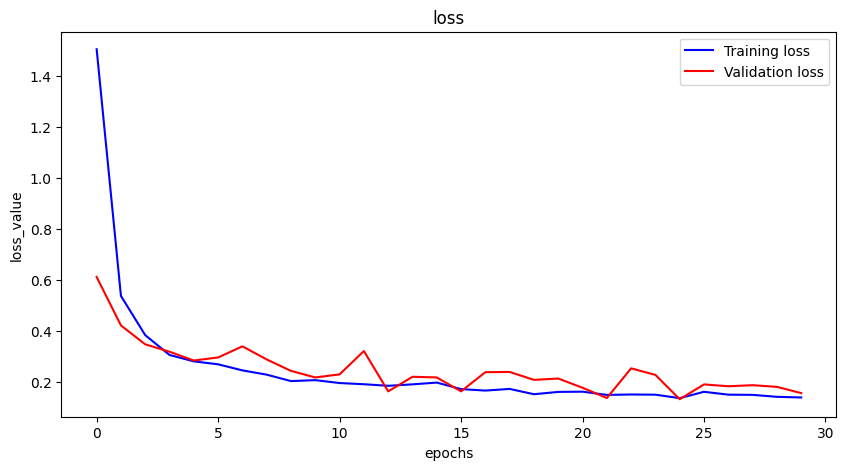

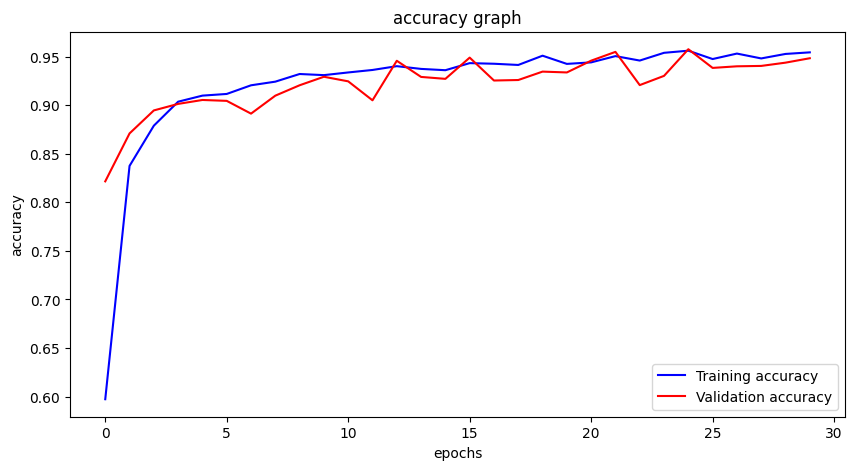

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(model_main.history.history['loss'],color='b',label='Training loss')
plt.plot(model_main.history.history['val_loss'],color='r',label='Validation loss')
plt.xlabel("epochs")
plt.ylabel("loss_value")
plt.title("loss")
plt.legend()

plt.figure(figsize=(10,5))
plt.plot(model_main.history.history['accuracy'],color='b',label='Training accuracy')
plt.plot(model_main.history.history['val_accuracy'],color='r',label='Validation accuracy')
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.title("accuracy graph")
plt.legend()

#Section 6: Initial Evaluation

In [16]:
model_main.load_weights('/content/drive/MyDrive/AgriSmart/model_weights/best_model.h5')
from sklearn.metrics import classification_report, confusion_matrix

eval_datagen = ImageDataGenerator()

eval_generator = eval_datagen.flow_from_directory(
    directory=path_valid,
    batch_size=32,
    target_size=(224,224),
    color_mode='rgb',
    class_mode='categorical',
    shuffle=False  # critical - keeps order fixed to match y_true
)

y_true = eval_generator.classes
steps = eval_generator.samples // eval_generator.batch_size + 1
y_pred_probs = model_main.predict(eval_generator, steps=steps, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = y_pred[:len(y_true)]

class_labels = list(eval_generator.class_indices.keys())
print(classification_report(y_true, y_pred, target_names=class_labels, digits=4))

cm = confusion_matrix(y_true, y_pred)

Found 17572 images belonging to 38 classes.
550/550 ━━━━━━━━━━━━━━━━━━━━ 47s 86ms/step
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.9539    0.9861    0.9698       504
                                 Apple___Black_rot     0.9760    0.9799    0.9779       497
                          Apple___Cedar_apple_rust     1.0000    0.9886    0.9943       440
                                   Apple___healthy     0.9633    0.9940    0.9784       502
                               Blueberry___healthy     0.9955    0.9802    0.9878       454
          Cherry_(including_sour)___Powdery_mildew     1.0000    0.9739    0.9868       421
                 Cherry_(including_sour)___healthy     0.9978    0.9956    0.9967       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.8971    0.9146    0.9058       410
                       Corn_(maize)___Common_rust_     1.0000    0.9811    0.9905   

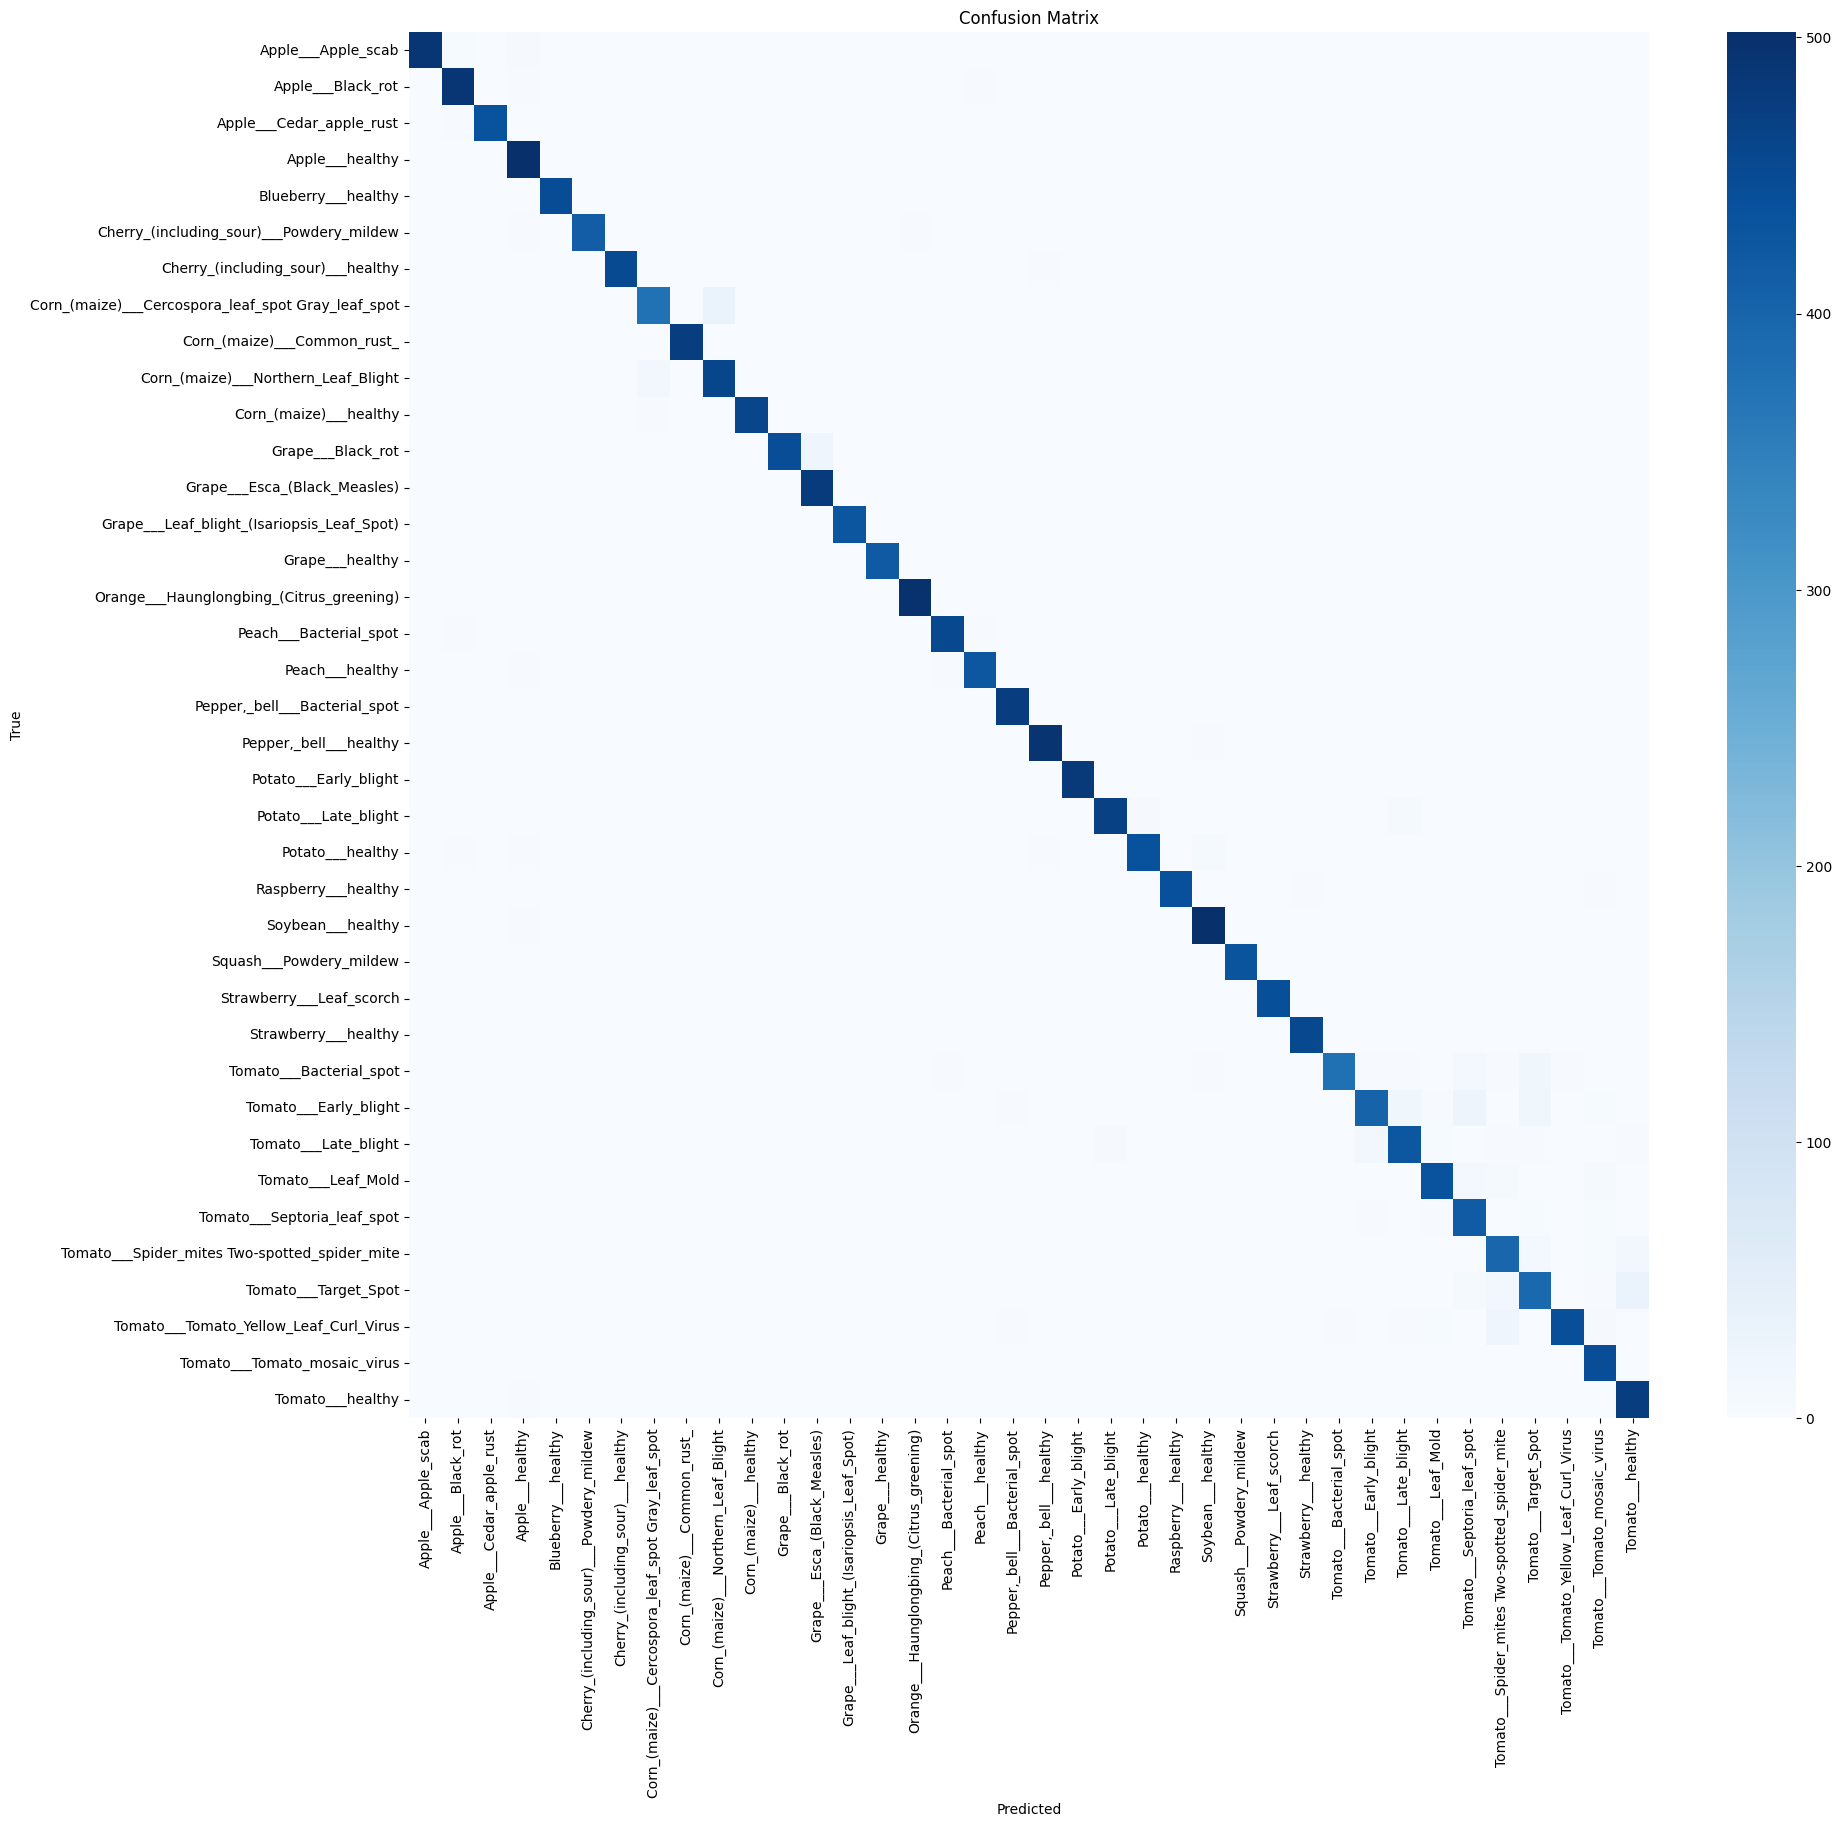

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20,18))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

#Section 7: Fine Tuning (Unfreezing Last Layers)

In [ ]:

model_main.load_weights('/content/drive/MyDrive/AgriSmart/model_weights/best_model.h5')

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
model_main.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ lambda[0][0]      │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ lambda[0][0]      │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    262,272 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 38)        │      2,470 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,860,710 (91.02 MB)

 Trainable params: 272,998 (1.04 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [18]:
# Unfreeze last ~30 layers of ResNet50 for fine-tuning
base_model_tf.trainable = True
for layer in base_model_tf.layers[:-30]:
    layer.trainable = False

# Recompile with a low learning rate
from tensorflow.keras.optimizers import Adam
model_main.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

# Callbacks (new filenames, won't touch original)
es = EarlyStopping(monitor='val_accuracy', verbose=1, patience=5, mode='auto')
mc = ModelCheckpoint(filepath='/content/drive/MyDrive/AgriSmart/model_weights/best_model_finetuned.weights.h5',
                      monitor='val_accuracy', verbose=1, save_best_only=True,
                      save_weights_only=True)
lr = ReduceLROnPlateau(monitor='val_accuracy', verbose=1, patience=3, min_lr=1e-7)

# fine-tune
model_main.fit(train, validation_data=valid, epochs=10, steps_per_epoch=200, verbose=1, callbacks=[mc, es, lr])

# CHANGED: save_weights() instead of save() - avoids bundling optimizer state
model_main.save_weights('/content/drive/MyDrive/AgriSmart/model_weights/RESNET50_FINETUNED.weights.h5')

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 579ms/step - accuracy: 0.8589 - loss: 0.4513
Epoch 1: val_accuracy improved from None to 0.95026, saving model to /content/drive/MyDrive/AgriSmart/model_weights/best_model_finetuned.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/AgriSmart/model_weights/best_model_finetuned.weights.h5
200/200 ━━━━━━━━━━━━━━━━━━━━ 192s 858ms/step - accuracy: 0.9019 - loss: 0.3105 - val_accuracy: 0.9503 - val_loss: 0.1510 - learning_rate: 1.0000e-05
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 549ms/step - accuracy: 0.9436 - loss: 0.1581
Epoch 2: val_accuracy improved from 0.95026 to 0.95664, saving model to /content/drive/MyDrive/AgriSmart/model_weights/best_model_finetuned.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/AgriSmart/model_weights/best_model_finetuned.weights.h5
200/200 ━━━━━━━━━━━━━━━━━━━━ 167s 836ms/step - accuracy: 0.9439 - loss: 0.1533 - val_accuracy: 0.9566 - val_loss: 0.1292 - learning_rate: 1.0000e-05

#Section 8: Final evaluation (Fine-Tuned)

In [19]:
model_main.load_weights('/content/drive/MyDrive/AgriSmart/model_weights/RESNET50_FINETUNED.weights.h5')
eval_datagen = ImageDataGenerator()
eval_generator = eval_datagen.flow_from_directory(
    directory=path_valid, batch_size=32, target_size=(224,224),
    color_mode='rgb', class_mode='categorical', shuffle=False
)

y_true = eval_generator.classes
steps = eval_generator.samples // eval_generator.batch_size + 1
y_pred_probs = model_main.predict(eval_generator, steps=steps, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = y_pred[:len(y_true)]

class_labels = list(eval_generator.class_indices.keys())
print(classification_report(y_true, y_pred, target_names=class_labels, digits=4))

cm = confusion_matrix(y_true, y_pred)

Found 17572 images belonging to 38 classes.
550/550 ━━━━━━━━━━━━━━━━━━━━ 59s 100ms/step
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.9940    0.9802    0.9870       504
                                 Apple___Black_rot     0.9782    0.9940    0.9860       497
                          Apple___Cedar_apple_rust     0.9977    0.9864    0.9920       440
                                   Apple___healthy     0.9653    0.9960    0.9804       502
                               Blueberry___healthy     0.9890    0.9934    0.9912       454
          Cherry_(including_sour)___Powdery_mildew     1.0000    0.9929    0.9964       421
                 Cherry_(including_sour)___healthy     0.9956    0.9978    0.9967       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.9552    0.9366    0.9458       410
                       Corn_(maize)___Common_rust_     0.9979    1.0000    0.9990  

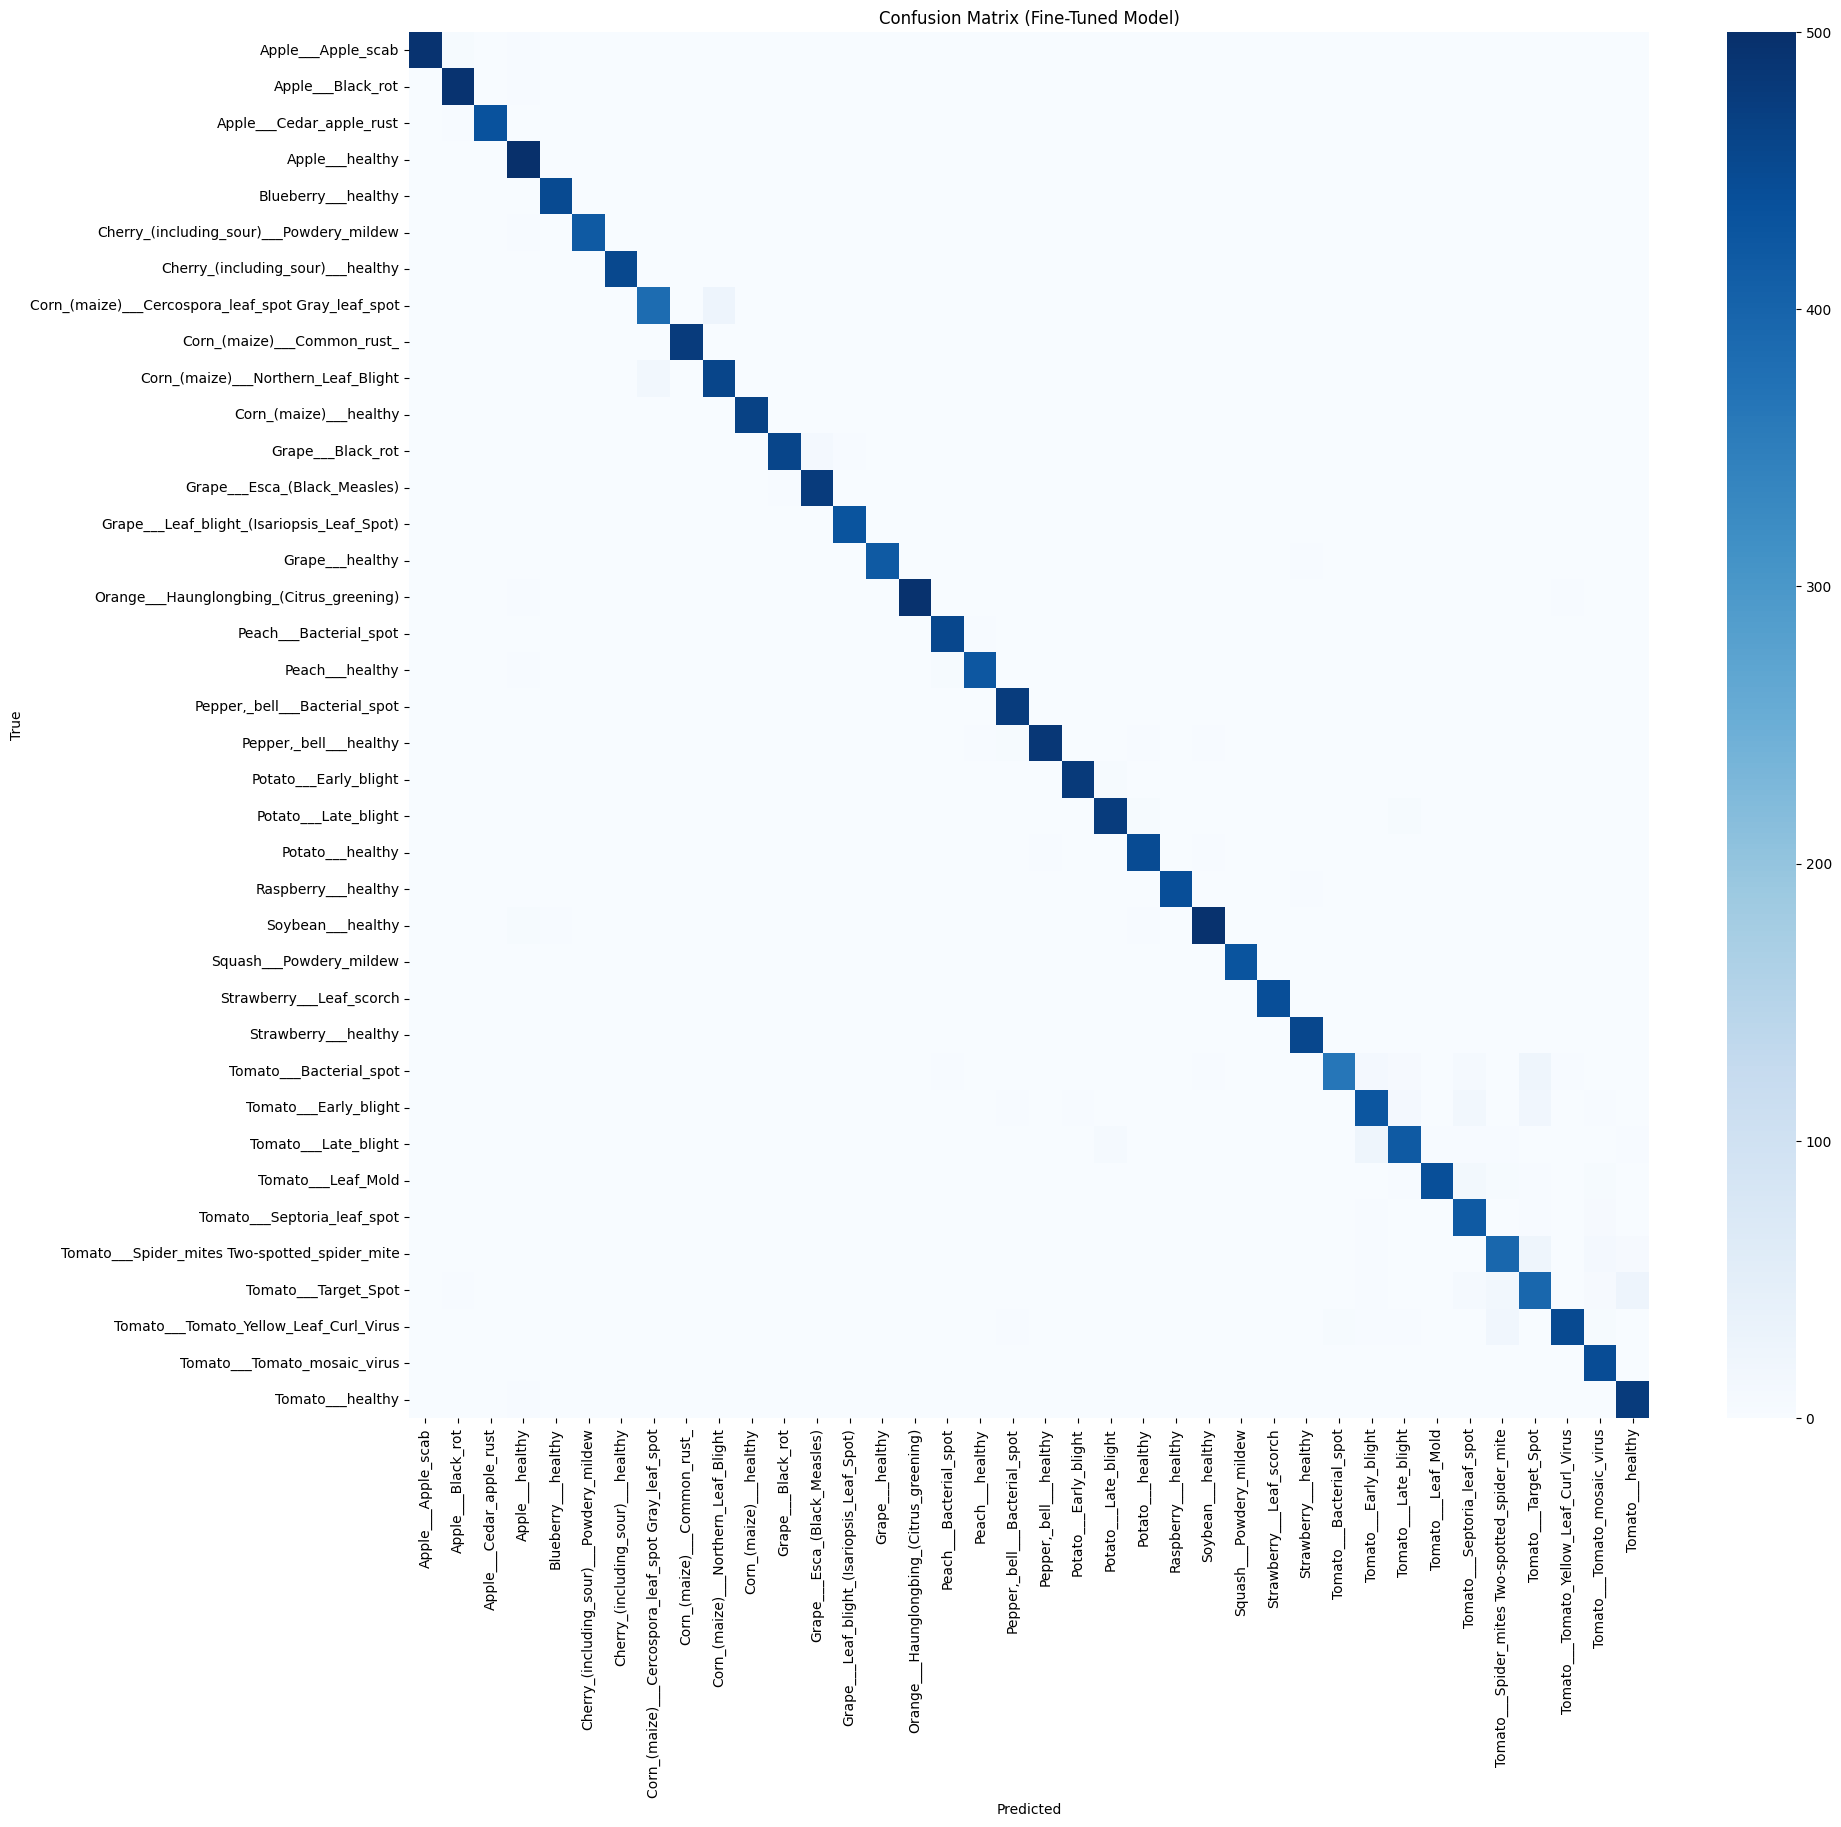

In [21]:
import seaborn as sns
plt.figure(figsize=(20,18))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Fine-Tuned Model)')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

#Section 9: Concrete Improvement Example

In [22]:
import numpy as np
import os
from tensorflow.keras.preprocessing import image

test_folder = '/content/plant_disease_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid/Tomato___Early_blight'
test_img_path = test_folder + '/' + os.listdir(test_folder)[0]

img = image.load_img(test_img_path, target_size=(224,224))
img_array = np.expand_dims(image.img_to_array(img), axis=0)
pred = model_main.predict(img_array)
print("Predicted class index:", np.argmax(pred), "Confidence:", np.max(pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Predicted class index: 29 Confidence: 0.9257922


In [23]:
class_labels = list(train.class_indices.keys())
print(class_labels[29])

Tomato___Early_blight


In [24]:
test_folder = '/content/plant_disease_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid/Apple___Cedar_apple_rust'
test_img_path = test_folder + '/' + os.listdir(test_folder)[0]

img = image.load_img(test_img_path, target_size=(224,224))
img_array = np.expand_dims(image.img_to_array(img), axis=0)
pred = model_main.predict(img_array)
predicted_idx = np.argmax(pred)
print("Predicted class index:", predicted_idx, "Confidence:", np.max(pred))
print("Predicted class name:", class_labels[predicted_idx])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Predicted class index: 2 Confidence: 0.9968997
Predicted class name: Apple___Cedar_apple_rust


#Section 10: Predict Function

In [ ]:
class_indices = train.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}

with open('/content/drive/MyDrive/AgriSmart/model_weights/class_indices.json', 'w') as f:
    json.dump(idx_to_class, f)

print(idx_to_class)

{0: 'Apple___Apple_scab', 1: 'Apple___Black_rot', 2: 'Apple___Cedar_apple_rust', 3: 'Apple___healthy', 4: 'Blueberry___healthy', 5: 'Cherry_(including_sour)___Powdery_mildew', 6: 'Cherry_(including_sour)___healthy', 7: 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 8: 'Corn_(maize)___Common_rust_', 9: 'Corn_(maize)___Northern_Leaf_Blight', 10: 'Corn_(maize)___healthy', 11: 'Grape___Black_rot', 12: 'Grape___Esca_(Black_Measles)', 13: 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 14: 'Grape___healthy', 15: 'Orange___Haunglongbing_(Citrus_greening)', 16: 'Peach___Bacterial_spot', 17: 'Peach___healthy', 18: 'Pepper,_bell___Bacterial_spot', 19: 'Pepper,_bell___healthy', 20: 'Potato___Early_blight', 21: 'Potato___Late_blight', 22: 'Potato___healthy', 23: 'Raspberry___healthy', 24: 'Soybean___healthy', 25: 'Squash___Powdery_mildew', 26: 'Strawberry___Leaf_scorch', 27: 'Strawberry___healthy', 28: 'Tomato___Bacterial_spot', 29: 'Tomato___Early_blight', 30: 'Tomato___Late_blight', 31: 'To

In [ ]:
def predict(image_path):
    img = image.load_img(image_path, target_size=(224, 224))
    img_array = np.expand_dims(image.img_to_array(img), axis=0)

    predictions = model_main.predict(img_array)
    predicted_index = int(np.argmax(predictions[0]))
    confidence = float(predictions[0][predicted_index])
    class_name = idx_to_class[predicted_index]

    return class_name, confidence

#Test
result = predict(test_img_path)
print(result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
('Corn_(maize)___Northern_Leaf_Blight', 0.0534784160554409)


## 11. Reloading the Model (No Retraining Needed)

`load_model()` fails on this saved file due to a Keras compatibility issue with
the Lambda layer used for preprocessing. The reliable approach is rebuilding the
same architecture and loading only the trained weights via `load_weights()`.

This section demonstrates that the final, fine-tuned model can be reloaded and
used for inference in a fresh session, without retraining — using only the
architecture, the saved weights file, and the class-index mapping produced
earlier in this notebook.

**Note:** this section assumes the dataset has already been downloaded and
unzipped (Section 1), since a real validation image is used for the test
prediction below.

In [26]:
import tensorflow
from tensorflow import keras
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model

# Rebuild architecture and load fine-tuned weights
base_model_tf = ResNet50(include_top=False, weights='imagenet', input_shape=(224,224,3), classes=38)
base_model_tf.trainable = False

pt = Input(shape=(224,224,3))
func = keras.layers.Lambda(lambda x: tensorflow.cast(x, tensorflow.float32))(pt)
x = preprocess_input(func)
model_resnet = base_model_tf(x, training=False)
model_resnet = GlobalAveragePooling2D()(model_resnet)
model_resnet = Dense(128, activation='relu')(model_resnet)
model_resnet = Dense(64, activation='relu')(model_resnet)
model_resnet = Dense(38, activation='softmax')(model_resnet)

model_main = Model(inputs=pt, outputs=model_resnet)
model_main.load_weights('/content/drive/MyDrive/AgriSmart/model_weights/RESNET50_FINETUNED.weights.h5')
model_main.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 224, 224,  │          0 │ input_layer_3[0]… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 224, 224)  │          0 │ lambda_1[0][0]    │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 224, 224)  │          0 │ lambda_1[0][0]    │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 224, 224)  │          0 │ lambda_1[0][0]    │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 224, 224,  │          0 │ get_item_3[0][0], │
│                     │ 3)                │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 224, 224,  │          0 │ stack_1[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add_1[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │    262,272 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      8,256 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 38)        │      2,470 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,860,710 (91.02 MB)

 Trainable params: 272,998 (1.04 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [32]:
import json
with open('/content/drive/MyDrive/AgriSmart/model_weights/class_indices.json') as f:
    idx_to_class_raw = json.load(f)
import os
import numpy as np
from tensorflow.keras.preprocessing import image
idx_to_class = {int(k): v for k, v in idx_to_class_raw.items()}

In [30]:


test_folder = '/content/plant_disease_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid/Apple___Cedar_apple_rust'
test_img_path = test_folder + '/' + os.listdir(test_folder)[0]

img = image.load_img(test_img_path, target_size=(224,224))
img_array = np.expand_dims(image.img_to_array(img), axis=0)
pred = model_main.predict(img_array)
predicted_idx = np.argmax(pred)
print("Predicted class index:", predicted_idx, "Confidence:", np.max(pred))
print("Predicted class name:", idx_to_class[predicted_idx])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Predicted class index: 2 Confidence: 0.9968997
Predicted class name: Apple___Cedar_apple_rust


### Result

The reloaded model correctly classifies the test image with high confidence,
confirming the saved weights (`RESNET50_FINETUNED.weights.h5`) and class-index
mapping (`class_indices.json`) are sufficient to reproduce working inference
without rerunning any training.

This is the same architecture, weights, and mapping used by the `predict()`
function and the backend API in this project's submission.